1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step


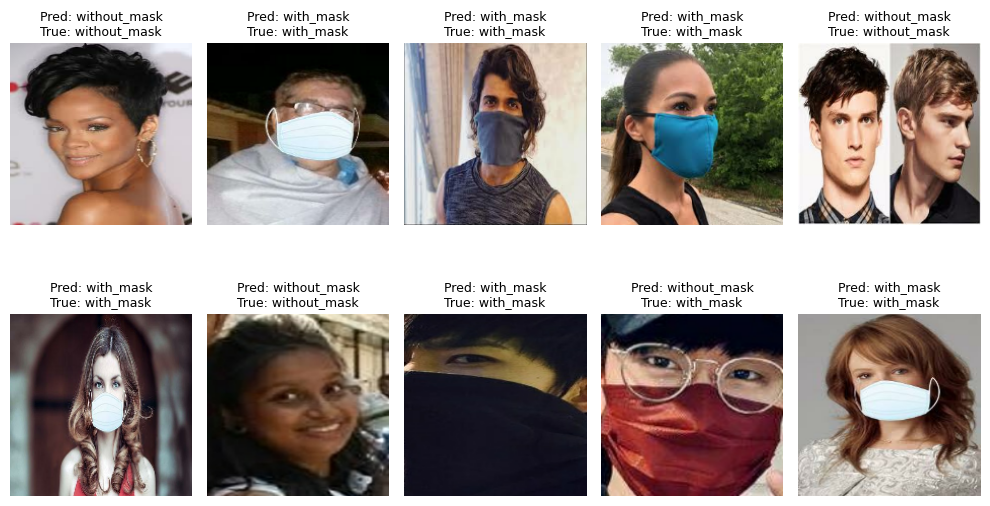

In [ ]:

### FACE MASK DETECTION USING CNN
##   Created by BAREERA MUSHTHAK



## Kaggle Dataset Download

# Upload the dataset zipfile downloaded from kaggle
from google.colab import files
files.upload()

# UNzip the downloaded dataset
import zipfile
#zip_ref=zipfile.ZipFile()
zip_ref=zipfile.ZipFile('archive (1).zip','r')
zip_ref.extractall('/content/facemask_dataset')
zip_ref.close()
import os
os.listdir('/content/facemask_dataset/data')

# load the dataset
from tensorflow.keras.utils import image_dataset_from_directory
train_dataset=image_dataset_from_directory('/content/facemask_dataset/data',
                                     validation_split=0.2,
                                     subset="training" ,
                                     seed=123,
                                     image_size=(180,180),
                                     label_mode='binary',
                                     batch_size=32,
                                     shuffle=True)
val_dataset=image_dataset_from_directory('/content/facemask_dataset/data',
                                     validation_split=0.2,
                                     subset="validation" ,
                                     seed=123,
                                     image_size=(180,180),
                                     label_mode='binary',
                                     batch_size=32,
                                     shuffle=True)

## Display some sample images
import matplotlib.pyplot as plt
class_names=train_dataset.class_names
fig=plt.figure(figsize=(10,6))
for images,labels in train_dataset.take(2):
  for i in range(20):
    ax=plt.subplot(2,10,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    label_text='Mask' if labels[i].numpy() ==0 else 'No Mask' # 1 for no mask and 0 for mask)
    plt.title(label_text)
    plt.axis("off")
plt.tight_layout()
fig.savefig("facemask_sample_images.png",dpi=300)
plt.show()

class_names=val_dataset.class_names
print("class_names", class_names)
#check label distribution in validation set
mask_count=0
no_mask_count=0
for images, labels in val_dataset:
  for label in labels:
    if label==0:
      mask_count+=1
    else:
      no_mask_count+=1
print("with mask", mask_count)
print("without mask",no_mask_count)

## Preprocessing
import tensorflow as tf
normalization_layer= tf.keras.layers.Rescaling(1./255)
train_dataset=train_dataset.map(lambda x,y:(normalization_layer(x),y))
val_dataset=val_dataset.map(lambda x,y:(normalization_layer(x),y))

## Build the CNN model
#Apply data augmentation
from tensorflow.keras.layers import RandomFlip,RandomRotation
import tensorflow as tf
data_augmentation=tf.keras.Sequential([RandomFlip("horizontal"),RandomRotation(0.1)])

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,Input
model= Sequential([
    Input((180,180,3)),
    data_augmentation,
    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])

## COMPILE AND TRAIN THE MODEL
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
history=model.fit(train_dataset,epochs=15,validation_data=val_dataset)

# save model
model.save("facemask.model.h5")

## EVALUATE THE MODEL
# Get true and predicted labels

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize lists
y_true = []
y_pred = []

# Predict and collect labels in the same loop to avoid mismatch
for images, labels in val_dataset:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int).flatten()  # Convert probabilities to binary
    y_pred.extend(preds)
    y_true.extend(labels.numpy())

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=['with_mask', 'without_mask']))


## Display some sample image
import matplotlib.pyplot as plt
import numpy as np

for images,labels in val_dataset.take(1):
  predictions=model.predict(images)
  predicted_labels=(predictions>0.5).astype(int)

  plt.figure(figsize=(10, 6))
  for i in range(10):  # Show 10 images
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow((images[i].numpy() * 255).astype("uint8"))

        # Label text: prediction and actual
        predicted = 'with_mask' if predicted_labels[i][0] == 0 else 'without_mask'
        actual = 'with_mask' if labels[i].numpy() == 0 else 'without_mask'
        plt.title(f"Pred: {predicted}\nTrue: {actual}", fontsize=9)
        plt.axis("off")

  plt.tight_layout()
  plt.savefig("sample_predictions.png", dpi=300)
  plt.show()

